## Simple Linear Regression

In [1]:
# Phase_0_setup.py
import pandas as pd
import numpy as np
from datetime import datetime
import os
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# 0. Configuration
# ----------------------------
RAW_PATH = "C:\\Users\\ASUS\\Downloads\\CA-1 DS\\cleaned_crop_insurance1.csv"   # input cleaned dataset (preserved as-is)
SNAPSHOT_DIR = "C:\\Users\\ASUS\\Downloads\\CA-1 DS\\snapshots"          # where to save timestamped snapshots
os.makedirs(SNAPSHOT_DIR, exist_ok=True)

# Essential columns we expect to use
ESSENTIAL_COLS = [
    "gross_premium", "sum_insured", "area_insured", "total_policies",
    "male", "female", "transgender",
    "sc", "st", "obc", "gen",
    "marginal", "small", "other",
    "scheme", "season", "state_name"
]

# Columns that are components of the target and should NOT be used raw as predictors
FORBIDDEN_PREDICTORS = ["farmer_share", "goi_share", "state_share"]

# ----------------------------
# 1. Load into a new modeling DataFrame (keep original file unchanged)
# ----------------------------
print("Loading cleaned dataset from:", RAW_PATH)
df_raw = pd.read_csv(RAW_PATH)
print("Original file loaded. Rows:", len(df_raw), "Columns:", len(df_raw.columns))

# Make a working copy for modeling
df_model = df_raw.copy()
print("Created df_model (working copy).")

# ----------------------------
# 2. Record versioning: save a timestamped snapshot of df_model
# ----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
snapshot_path = os.path.join(SNAPSHOT_DIR, f"df_model_snapshot_{ts}.csv")
df_model.to_csv(snapshot_path, index=False)
print(f"Saved snapshot: {snapshot_path}  (rows: {len(df_model)})")

# ----------------------------
# 3. Confirm presence of essential columns and basic sanity checks
# ----------------------------
print("\nChecking for essential columns...")
missing_cols = [c for c in ESSENTIAL_COLS if c not in df_model.columns]
if missing_cols:
    print("WARNING: The following ESSENTIAL columns are MISSING from df_model:")
    for c in missing_cols:
        print(" -", c)
    print("Please check the raw data or column name mismatches (typos / case differences).")
else:
    print("All essential columns present.")

# Show dtypes for essential columns (if present)
print("\nData types of available essential columns:")
for c in ESSENTIAL_COLS:
    if c in df_model.columns:
        print(f" - {c}: {df_model[c].dtype}")

# ----------------------------
# 4. Replace or coerce numeric columns & quick statistics
# ----------------------------
numeric_cols_to_check = ["gross_premium", "sum_insured", "area_insured", "total_policies"]
for col in numeric_cols_to_check:
    if col in df_model.columns:
        # coerce to numeric (safe)
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

print("\nBasic stats for core numeric columns:")
print(df_model[numeric_cols_to_check].describe().T[['count','mean','std','min','25%','50%','75%','max']])

# Missing and zero counts for core numeric columns
print("\nMissing and zero counts (core numeric columns):")
for col in numeric_cols_to_check:
    if col in df_model.columns:
        missing = df_model[col].isna().sum()
        zeros = (df_model[col] == 0).sum()
        print(f" - {col}: missing={missing} ({missing/len(df_model):.2%}), zeros={zeros} ({zeros/len(df_model):.2%})")

# ----------------------------
# 5. Drop rows with total_policies NaN (or handle explicitly)
# ----------------------------
if "total_policies" in df_model.columns:
    before = len(df_model)
    # If total_policies is float with NaNs, drop those rows for now (you can save them separately)
    df_model = df_model.dropna(subset=["total_policies"]).copy()
    after = len(df_model)
    dropped = before - after
    print(f"\nDropped {dropped} rows with NaN total_policies. Rows now: {after}")
else:
    print("\nColumn 'total_policies' not found - cannot drop NaNs. Please inspect your data.")

# ----------------------------
# 6. Demographic percentage validation (sum to ~100)
# ----------------------------
print("\nValidating demographic percentage sums (where columns exist)...")
# Gender sum
gender_cols = [c for c in ["male","female","transgender"] if c in df_model.columns]
if gender_cols:
    gender_sum = df_model[gender_cols].sum(axis=1)
    print("Gender sum stats (min, median, mean, max):", gender_sum.min(), gender_sum.median(), gender_sum.mean(), gender_sum.max())
    bad_gender = ((gender_sum < 99.0) | (gender_sum > 101.0)).sum()
    print(f"Rows where gender % sum is not ~100: {bad_gender} out of {len(df_model)} ({bad_gender/len(df_model):.2%})")
else:
    print("Gender percentage columns not available to validate.")

# Caste sum
caste_cols = [c for c in ["sc","st","obc","gen"] if c in df_model.columns]
if caste_cols:
    caste_sum = df_model[caste_cols].sum(axis=1)
    print("Caste sum stats (min, median, mean, max):", caste_sum.min(), caste_sum.median(), caste_sum.mean(), caste_sum.max())
    bad_caste = ((caste_sum < 99.0) | (caste_sum > 101.0)).sum()
    print(f"Rows where caste % sum is not ~100: {bad_caste} out of {len(df_model)} ({bad_caste/len(df_model):.2%})")
else:
    print("Caste percentage columns not available to validate.")

# Farmer type sum
ftype_cols = [c for c in ["marginal","small","other"] if c in df_model.columns]
if ftype_cols:
    ftype_sum = df_model[ftype_cols].sum(axis=1)
    print("Farmer-type sum stats (min, median, mean, max):", ftype_sum.min(), ftype_sum.median(), ftype_sum.mean(), ftype_sum.max())
    bad_ftype = ((ftype_sum < 99.0) | (ftype_sum > 101.0)).sum()
    print(f"Rows where farmer-type % sum is not ~100: {bad_ftype} out of {len(df_model)} ({bad_ftype/len(df_model):.2%})")
else:
    print("Farmer-type percentage columns not available to validate.")

# ----------------------------
# 7. Warn about forbidden predictors (premium components)
# ----------------------------
present_forbidden = [c for c in FORBIDDEN_PREDICTORS if c in df_model.columns]
if present_forbidden:
    print("\nWARNING: The following columns are present and are components of the gross_premium target:")
    for c in present_forbidden:
        print(" -", c)
    print("Do NOT include these raw amount columns as predictors in models that predict gross_premium (they cause leakage).")
else:
    print("\nNo premium-component amount columns found. Good.")

# ----------------------------
# 8. Final snapshot of df_model after Phase 0 changes
# ----------------------------
final_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_snapshot_path = os.path.join(SNAPSHOT_DIR, f"df_model_after_phase0_{final_ts}.csv")
df_model.to_csv(final_snapshot_path, index=False)
print(f"\nSaved post-Phase-0 snapshot: {final_snapshot_path}  (rows: {len(df_model)})")

print("\nPhase 0 complete. Next: Phase 1 (Simple Linear Regression baseline).")


Loading cleaned dataset from: C:\Users\ASUS\Downloads\CA-1 DS\cleaned_crop_insurance1.csv
Original file loaded. Rows: 5694 Columns: 26
Created df_model (working copy).
Saved snapshot: C:\Users\ASUS\Downloads\CA-1 DS\snapshots\df_model_snapshot_20250820_140237.csv  (rows: 5694)

Checking for essential columns...
All essential columns present.

Data types of available essential columns:
 - gross_premium: float64
 - sum_insured: float64
 - area_insured: float64
 - total_policies: float64
 - male: float64
 - female: float64
 - transgender: float64
 - sc: float64
 - st: float64
 - obc: float64
 - gen: float64
 - marginal: float64
 - small: float64
 - other: float64
 - scheme: object
 - season: object
 - state_name: object

Basic stats for core numeric columns:
                 count          mean            std  min     25%        50%  \
gross_premium   5694.0   2440.662244    6400.997652  0.0   18.48    284.530   
sum_insured     5694.0  17304.934445   33982.046269  0.0  183.02   3551.235 

Loaded rows: 5693
Rows after dropping NA in core cols: 5693

Core stats (original units):
                count          mean      50%           std  min        max
gross_premium  5693.0   2441.090957   284.56   6401.478152  0.0   80103.40
sum_insured    5693.0  17307.974131  3551.62  33984.257035  0.0  535572.47

Train rows: 4554  Test rows: 1139

=== OLS Summary (train) ===
                            OLS Regression Results                            
Dep. Variable:      log_gross_premium   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                 4.897e+04
Date:                Wed, 20 Aug 2025   Prob (F-statistic):               0.00
Time:                        14:10:12   Log-Likelihood:                -5543.5
No. Observations:                4554   AIC:                         1.109e+04
Df Residuals:                    4552   BIC:                        

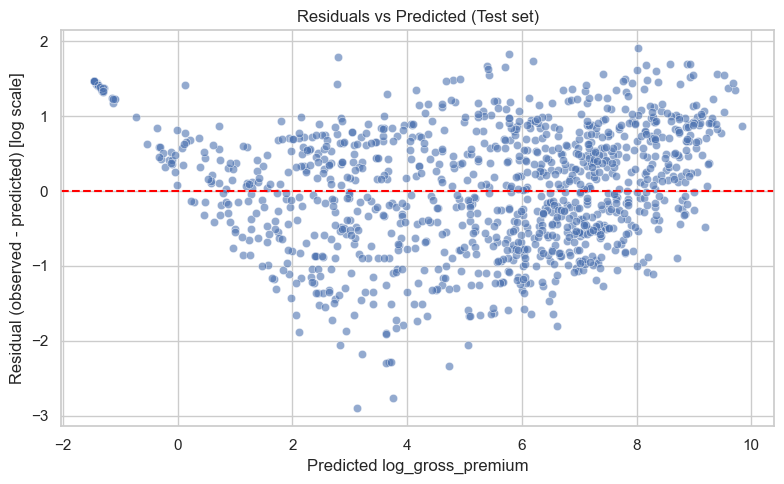

<Figure size 600x600 with 0 Axes>

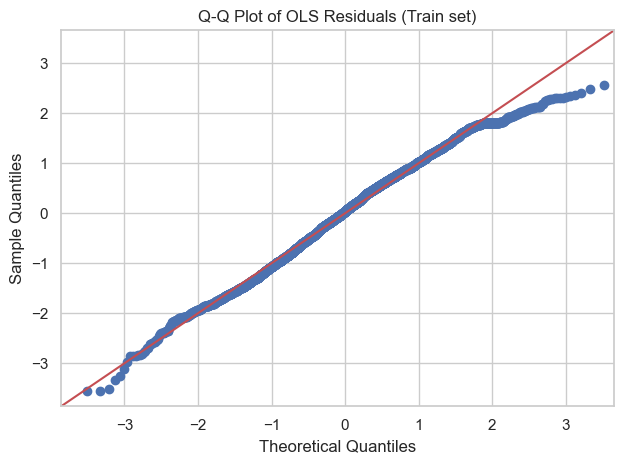

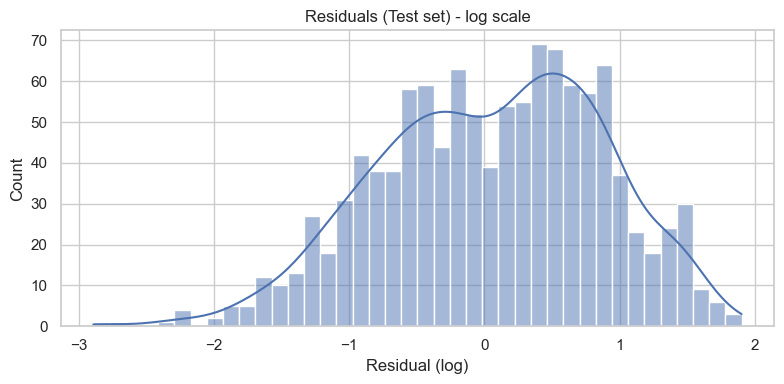


=== OLS Summary with HC3 robust SEs ===
                            OLS Regression Results                            
Dep. Variable:      log_gross_premium   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                 4.140e+04
Date:                Wed, 20 Aug 2025   Prob (F-statistic):               0.00
Time:                        14:10:13   Log-Likelihood:                -5543.5
No. Observations:                4554   AIC:                         1.109e+04
Df Residuals:                    4552   BIC:                         1.110e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
c

In [2]:
# Phase1_Simple_Linear_Regression.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ----------------------------
# 0. Config
# ----------------------------
DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\df_model_after_phase0_20250820_140237.csv"   # change if you use a snapshot
RANDOM_STATE = 42
TEST_SIZE = 0.20

# ----------------------------
# 1. Load & prepare data
# ----------------------------
df = pd.read_csv(DATA_PATH)
print("Loaded rows:", len(df))

# Ensure core columns exist
for c in ["gross_premium", "sum_insured"]:
    if c not in df.columns:
        raise SystemExit(f"ERROR: '{c}' not found in dataset. Check column names.")

# Coerce to numeric and drop NA for these two columns
df["gross_premium"] = pd.to_numeric(df["gross_premium"], errors="coerce")
df["sum_insured"] = pd.to_numeric(df["sum_insured"], errors="coerce")

# Drop rows missing target or predictor
df_model = df.dropna(subset=["gross_premium", "sum_insured"]).copy()
print("Rows after dropping NA in core cols:", len(df_model))

# Create log1p transforms
df_model["log_gross_premium"] = np.log1p(df_model["gross_premium"])
df_model["log_sum_insured"] = np.log1p(df_model["sum_insured"])

# Quick sanity stats
print("\nCore stats (original units):")
print(df_model[["gross_premium", "sum_insured"]].describe().T[["count","mean","50%","std","min","max"]])

# ----------------------------
# 2. Train/test split
# ----------------------------
X = df_model[["log_sum_insured"]]   # 2D
y = df_model["log_gross_premium"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"\nTrain rows: {len(X_train)}  Test rows: {len(X_test)}")

# ----------------------------
# 3. Fit simple OLS (statsmodels)
# ----------------------------
X_train_sm = sm.add_constant(X_train)   # adds intercept
model = sm.OLS(y_train, X_train_sm).fit()
print("\n=== OLS Summary (train) ===")
print(model.summary())

# ----------------------------
# 4. Predictions & evaluation (test set)
# ----------------------------
X_test_sm = sm.add_constant(X_test)
y_pred_log = model.predict(X_test_sm)      # predictions on log scale

# Metrics on log scale
r2 = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
print(f"\nTest set (log-scale) metrics: R2 = {r2:.4f}, RMSE_log = {rmse_log:.4f}, MAE_log = {mae_log:.4f}")

# Inverse transform to original INR scale
y_test_orig = np.expm1(y_test)        # expm1 undoes log1p
y_pred_orig = np.expm1(y_pred_log)

rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
print(f"Test set (INR) metrics: RMSE = ₹{rmse_orig:,.2f}, MAE = ₹{mae_orig:,.2f}")

# Baseline percentage error for context
mape = (np.abs((y_test_orig - y_pred_orig) / (y_test_orig.replace(0, np.nan)))).dropna().mean() * 100
print(f"Approx Mean Absolute Percentage Error (MAPE) on non-zero test rows: {mape:.2f}%")

# ----------------------------
# 5. Diagnostic plots
# ----------------------------
# Residuals vs Fitted (test)
residuals_test = y_test - y_pred_log
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_log, y=residuals_test, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted log_gross_premium")
plt.ylabel("Residual (observed - predicted) [log scale]")
plt.title("Residuals vs Predicted (Test set)")
plt.tight_layout()
plt.show()

# Q-Q plot of training residuals
plt.figure(figsize=(6,6))
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot of OLS Residuals (Train set)")
plt.tight_layout()
plt.show()

# Histogram of residuals (test)
plt.figure(figsize=(8,4))
sns.histplot(residuals_test, bins=40, kde=True)
plt.title("Residuals (Test set) - log scale")
plt.xlabel("Residual (log)")
plt.tight_layout()
plt.show()

# ----------------------------
# 6. Robust standard errors (HC3) if heteroscedasticity suspected
# ----------------------------
robust_res = model.get_robustcov_results(cov_type='HC3')
print("\n=== OLS Summary with HC3 robust SEs ===")
print(robust_res.summary())

# ----------------------------
# 7. Business-friendly effect size: what does +₹100,000 in sum_insured mean?
# ----------------------------
delta_inr = 100_000

# Choose a reference x: use median sum_insured to be robust
ref_x = df_model["sum_insured"].median()
ref_logx = np.log1p(ref_x)
ref_logx_plus = np.log1p(ref_x + delta_inr)

# Predict log_y at ref and ref+delta using the trained model coefficients
const = model.params.get("const", model.params[0])
slope = model.params.get("log_sum_insured", model.params[1])

pred_log_ref = const + slope * ref_logx
pred_log_ref_plus = const + slope * ref_logx_plus

pred_inr_ref = np.expm1(pred_log_ref)
pred_inr_ref_plus = np.expm1(pred_log_ref_plus)
diff_inr = pred_inr_ref_plus - pred_inr_ref
pct_change = (diff_inr / pred_inr_ref) * 100 if pred_inr_ref != 0 else np.nan

print("\nBusiness interpretation at median sum_insured:")
print(f" - Reference sum_insured (median) = ₹{ref_x:,.0f}")
print(f" - Predicted gross_premium at reference = ₹{pred_inr_ref:,.2f}")
print(f" - Predicted gross_premium at reference + ₹{delta_inr} = ₹{pred_inr_ref_plus:,.2f}")
print(f" - Absolute increase in premium ≈ ₹{diff_inr:,.2f} (≈ {pct_change:.2f}% increase)")

# Also show elasticity (slope) interpretation (approx)
print(f"\nElasticity (slope b on log-log): b = {slope:.4f}")
print("Interpretation: a 1% increase in sum_insured -> approx b% increase in gross_premium (local elasticity).")

# ----------------------------
# 8. Save outputs (optional)
# ----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_txt = f"phase1_simple_regression_summary_{ts}.txt"
with open(summary_txt, "w") as f:
    f.write("Simple OLS summary (train):\n")
    f.write(model.summary().as_text())
    f.write("\n\nOLS HC3 robust summary:\n")
    f.write(robust_res.summary().as_text())
    f.write("\n\nTest metrics (log & INR):\n")
    f.write(f"R2_log_test: {r2}\nRMSE_log_test: {rmse_log}\nMAE_log_test: {mae_log}\n")
    f.write(f"RMSE_INR_test: {rmse_orig}\nMAE_INR_test: {mae_orig}\n")
print(f"\nSaved textual summaries to {summary_txt}")

# Done
print("\nPhase 1 complete. Next: Phase 2 (Multiple regression).")


- Model fit is excellent.
The simple log–log OLS (log(gross_premium) ~ log(sum_insured)) explains ~91.5% of variance (R² ≈ 0.915). That means sum_insured alone is a very powerful predictor of gross_premium — as expected.

- Estimated relationship (elasticity):
The slope b = 0.8979 (highly significant, p ≈ 0) from the OLS means: a 1% increase in sum_insured is associated with approximately a 0.898% increase in gross_premium (local elasticity). This is the best, compact statement of the relationship.

Prediction error (practical scale):

- RMSE on the INR scale ≈ ₹4,962 (typical prediction error magnitude).

- MAE ≈ ₹1,516 (median-ish absolute error).
These give you business-level sense of how far predictions are from reality (on average).

Residual diagnostics:

- Q-Q and histogram: residuals are approximately normal — checks out for OLS assumptions.

- Residuals vs predicted: looks like no obvious heteroscedastic pattern. Good.

- Robust HC3 results barely changed the coefficient or SEs, confirming robustness.

1. We've Proven the Main Engine ⚙️
We confirmed with high confidence (R 
2
 =91.5%) that the sum_insured is the single most important factor driving the gross_premium. This might seem obvious, but we've moved from a simple correlation in the EDA to a statistically proven, predictive relationship.

2. We've Created a Precise "Rule of Thumb" 📏
We now have a specific number that describes how these two variables are linked. The model gave us an elasticity of about 0.9.

In plain English: This means for every 1% increase in the value of the crops being insured, the premium increases by roughly 0.9%. This is a powerful and practical financial insight.

3. We've Established a Performance Benchmark 📊
This simple model is now our baseline. We know its average prediction error is about ₹1,516 (MAE). Any more complex model we build next must be more accurate than this to be considered an improvement. We now have a score to beat.

4. We've Found a Clear Map for What to Do Next 🗺️
Most importantly, the model's imperfections have shown us the way forward. The "fan shape" in the residual plot tells us that the relationship isn't just about the sum_insured. There are other factors (like state, scheme, or season) that the model is missing, especially for more expensive policies.

So, we've essentially built a strong foundation. It's solid, but now we know exactly where to add more supports (new variables) to make our prediction model much better.

## Multiple Linear Regression

In [1]:
# Phase2_prep_features.py
"""
Step A-C: Prepare target, decide on zero-uptake handling, and create candidate features
for multiple regression.

Outputs:
 - processed dataframe saved to model_snapshots/processed_features_{timestamp}.csv
 - preprocessing artifacts (StandardScaler) saved to model_snapshots/scaler_{timestamp}.pkl
 - JSON summary of selected features saved to model_snapshots/features_{timestamp}.json

Run this after Phase 0 & Phase 1 snapshots. It does NOT modify original files.
"""

import pandas as pd
import numpy as np
import os
from datetime import datetime
import json
import joblib
from sklearn.preprocessing import StandardScaler

# -----------------------------
# User-configurable parameters
# -----------------------------
DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\df_model_after_phase0_20250820_140237.csv"   # or the Phase-0 snapshot filename you prefer
SNAPSHOT_DIR = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots"
os.makedirs(SNAPSHOT_DIR, exist_ok=True)

TOP_N_STATES = 10            # number of top states to create dummies for (others => "Other")
KEEP_ZERO_UPTAKE = True      # if False, drop rows where sum_insured==0 & gross_premium==0
STANDARDIZE_FOR_REGULARIZATION = True   # create a scaler and standardized features for Lasso/Ridge later
ADD_INTERACTIONS = True      # add scheme*log_sum_insured and season*log_sum_insured
USE_STATE_PC1 = False        # alternative: compute state-level PC1 and use it instead of dummies (optional)

# -----------------------------
# 0. Load working dataset (do not overwrite originals)
# -----------------------------
print("Loading data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Rows loaded:", len(df))

# Keep a working copy
df_model = df.copy()

# -----------------------------
# 1. Target form
# -----------------------------
# Create target and transformed target
df_model['gross_premium'] = pd.to_numeric(df_model['gross_premium'], errors='coerce')
df_model['sum_insured'] = pd.to_numeric(df_model['sum_insured'], errors='coerce')
df_model['area_insured'] = pd.to_numeric(df_model.get('area_insured', np.nan), errors='coerce')
df_model['total_policies'] = pd.to_numeric(df_model.get('total_policies', np.nan), errors='coerce')

# Target: log1p(gross_premium)
df_model['log_gross_premium'] = np.log1p(df_model['gross_premium'])

print("\nTarget created: log_gross_premium (log1p of gross_premium).")

# -----------------------------
# 2. Zero-uptake rows handling
# -----------------------------
zero_uptake_mask = (df_model['sum_insured'].fillna(0) == 0) & (df_model['gross_premium'].fillna(0) == 0)
n_zero_uptake = zero_uptake_mask.sum()
print(f"\nZero-uptake rows (sum_insured==0 & gross_premium==0): {n_zero_uptake} / {len(df_model)} "
      f"({n_zero_uptake/len(df_model):.2%})")

if not KEEP_ZERO_UPTAKE:
    df_model = df_model.loc[~zero_uptake_mask].copy()
    print("Dropped zero-uptake rows. New row count:", len(df_model))
else:
    print("Keeping zero-uptake rows in the dataset (recommended for coverage modeling).")

# -----------------------------
# 3. Create log1p transforms for numeric skewed predictors
# -----------------------------
# Required predictors
df_model['log_sum_insured'] = np.log1p(df_model['sum_insured'])
df_model['log_area_insured'] = np.log1p(df_model['area_insured'].fillna(0))
df_model['log_total_policies'] = np.log1p(df_model['total_policies'].fillna(0))

print("\nCreated log1p transforms for sum_insured, area_insured, total_policies.")

# -----------------------------
# 4. Encode simple categoricals
# -----------------------------
# scheme and season encoding (binary)
if 'scheme' in df_model.columns:
    df_model['scheme_encoded'] = df_model['scheme'].map({'PMFBY': 1, 'WBCIS': 0})
    if df_model['scheme_encoded'].isna().any():
        # unknown schemes -> fill with 0 and warn
        n_unknown = df_model['scheme_encoded'].isna().sum()
        print(f"WARNING: {n_unknown} rows have unknown scheme values; filling with 0.")
        df_model['scheme_encoded'] = df_model['scheme_encoded'].fillna(0)
else:
    df_model['scheme_encoded'] = 0
    print("Note: 'scheme' column not found; created scheme_encoded=0 fallback.")

if 'season' in df_model.columns:
    df_model['season_encoded'] = df_model['season'].map({'Kharif': 1, 'Rabi': 0})
    if df_model['season_encoded'].isna().any():
        n_unknown = df_model['season_encoded'].isna().sum()
        print(f"WARNING: {n_unknown} rows have unknown season values; filling with 0.")
        df_model['season_encoded'] = df_model['season_encoded'].fillna(0)
else:
    df_model['season_encoded'] = 0
    print("Note: 'season' column not found; created season_encoded=0 fallback.")

print("Created scheme_encoded and season_encoded binary flags.")

# -----------------------------
# 5. State handling: top-N dummies + Other
# -----------------------------
if USE_STATE_PC1:
    print("\nUSE_STATE_PC1=True selected. Computing state PC1 (requires aggregated numeric features).")
    # compute state-level PCA (optional) - placeholder: derive state mean sum_insured as state score
    state_score = df_model.groupby('state_name')['sum_insured'].median().rename('state_median_sum_insured')
    df_model = df_model.merge(state_score.reset_index(), on='state_name', how='left')
    # normalize to 0-1
    df_model['state_PC1'] = (df_model['state_median_sum_insured'] - df_model['state_median_sum_insured'].mean()) / \
                             df_model['state_median_sum_insured'].std()
    print("Computed state_PC1 using median sum_insured per state (proxy).")
    state_dummy_cols = []
else:
    top_states = df_model['state_name'].value_counts().nlargest(TOP_N_STATES).index.tolist()
    print(f"\nTop {TOP_N_STATES} states (by row count):\n", top_states)
    # Create dummy columns like state_is_<name> (safe column names)
    state_dummy_cols = []
    for s in top_states:
        col = f"state_is_{s.replace(' ', '_').replace('&','and')}"
        df_model[col] = (df_model['state_name'] == s).astype(int)
        state_dummy_cols.append(col)
    # Create an 'other' indicator (optional)
    df_model['state_is_Other'] = (~df_model['state_name'].isin(top_states)).astype(int)
    state_dummy_cols.append('state_is_Other')
    print(f"Created state dummies for top states + 'Other' (columns: {len(state_dummy_cols)}).")

# -----------------------------
# 6. Demographic columns: include if present
# -----------------------------
demographics = []
for c in ['female', 'marginal', 'small']:
    if c in df_model.columns:
        df_model[c] = pd.to_numeric(df_model[c], errors='coerce')
        demographics.append(c)
    else:
        print(f"Note: demographic column '{c}' not found; it will be excluded from features.")

print("\nDemographic columns included:", demographics)

# -----------------------------
# 7. Candidate feature list (final)
# -----------------------------
numeric_features = ['log_sum_insured', 'log_area_insured', 'log_total_policies']
numeric_features += []  # placeholder for scaled versions later

cat_features = ['scheme_encoded', 'season_encoded']
cat_features += state_dummy_cols  # may be empty if using state_PC1

features = numeric_features + demographics + cat_features

# Add optional interactions
if ADD_INTERACTIONS:
    # interaction names
    inter1 = 'scheme_x_log_sum_insured'
    inter2 = 'season_x_log_sum_insured'
    df_model[inter1] = df_model['scheme_encoded'] * df_model['log_sum_insured']
    df_model[inter2] = df_model['season_encoded'] * df_model['log_sum_insured']
    features += [inter1, inter2]
    print("\nAdded interaction features:", inter1, inter2)

# Remove forbidden predictors (raw subsidy amounts) if present
for forbidden in ['farmer_share', 'goi_share', 'state_share']:
    if forbidden in features:
        features.remove(forbidden)
forbidden_present = [c for c in ['farmer_share', 'goi_share', 'state_share'] if c in df_model.columns]
if forbidden_present:
    print("\nNOTE: Found premium-component columns in dataset (will not be used as raw predictors):", forbidden_present)

# Filter out any features that don't actually exist (safety)
features = [f for f in features if f in df_model.columns]
print("\nFinal feature list ({} features):".format(len(features)))
print(features)

# -----------------------------
# 8. Missing value handling for feature columns & final rows
# -----------------------------
print("\nMissing values per chosen feature (counts):")
missing_counts = df_model[features].isna().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

# Drop rows with NaNs in essential features or target (we need rows for modeling)
before_rows = len(df_model)
df_model = df_model.dropna(subset=features + ['log_gross_premium']).copy()
after_rows = len(df_model)
print(f"\nDropped {before_rows - after_rows} rows due to NaNs in features/target. Rows available for modeling: {after_rows}")

# -----------------------------
# 9. Standardize numeric features (optional)
# -----------------------------
scaler = None
scaled_feature_names = []
if STANDARDIZE_FOR_REGULARIZATION:
    # We'll create scaled versions of numeric features for Lasso/Ridge later, keep originals for OLS interpretability
    scaler = StandardScaler()
    to_scale = [c for c in numeric_features if c in df_model.columns]
    if to_scale:
        scaled_vals = scaler.fit_transform(df_model[to_scale])
        for i, c in enumerate(to_scale):
            sc_name = f"{c}_std"
            df_model[sc_name] = scaled_vals[:, i]
            scaled_feature_names.append(sc_name)
        print("\nStandardized numeric features (created '_std' columns):", scaled_feature_names)
    else:
        print("\nNo numeric features found to scale.")
else:
    print("\nSTANDARDIZE_FOR_REGULARIZATION=False -> no scaling performed.")

# -----------------------------
# 10. Save processed snapshot and artifacts
# -----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
processed_path = os.path.join(SNAPSHOT_DIR, f"processed_features_{ts}.csv")
df_model.to_csv(processed_path, index=False)
print(f"\nSaved processed dataset snapshot: {processed_path} (rows: {len(df_model)})")

# Save scaler artifact if created
if scaler is not None:
    scaler_path = os.path.join(SNAPSHOT_DIR, f"scaler_{ts}.pkl")
    joblib.dump(scaler, scaler_path)
    print("Saved StandardScaler to:", scaler_path)
else:
    scaler_path = None

# Save features JSON
feature_summary = {
    "timestamp": ts,
    "n_rows": len(df_model),
    "features": features,
    "scaled_features": scaled_feature_names,
    "target": "log_gross_premium",
    "keep_zero_uptake": KEEP_ZERO_UPTAKE,
    "top_n_states": TOP_N_STATES,
    "use_state_pc1": USE_STATE_PC1,
}
features_json_path = os.path.join(SNAPSHOT_DIR, f"features_summary_{ts}.json")
with open(features_json_path, "w") as f:
    json.dump(feature_summary, f, indent=2)
print("Saved feature summary to:", features_json_path)

# -----------------------------
# 11. Print final readiness summary
# -----------------------------
print("\n=== READY FOR MODELING ===")
print(f"Rows ready for modeling: {len(df_model)}")
print("Target: log_gross_premium")
print("Features (first 30 shown):", features[:30])
if scaled_feature_names:
    print("Scaled features available for regularized models:", scaled_feature_names)
print("\nNext: run your multiple regression using 'features' (for OLS interpretability) or use scaled_features for Lasso/Ridge.")


Loading data from: C:\Users\ASUS\Downloads\CA-1 DS\snapshots\df_model_after_phase0_20250820_140237.csv
Rows loaded: 5693

Target created: log_gross_premium (log1p of gross_premium).

Zero-uptake rows (sum_insured==0 & gross_premium==0): 70 / 5693 (1.23%)
Keeping zero-uptake rows in the dataset (recommended for coverage modeling).

Created log1p transforms for sum_insured, area_insured, total_policies.
Created scheme_encoded and season_encoded binary flags.

Top 10 states (by row count):
 ['Uttar Pradesh', 'Madhya Pradesh', 'Maharashtra', 'Chhattisgarh', 'Rajasthan', 'Tamil Nadu', 'Odisha', 'Assam', 'Uttarakhand', 'Telangana']
Created state dummies for top states + 'Other' (columns: 11).

Demographic columns included: ['female', 'marginal', 'small']

Added interaction features: scheme_x_log_sum_insured season_x_log_sum_insured

NOTE: Found premium-component columns in dataset (will not be used as raw predictors): ['farmer_share', 'goi_share', 'state_share']

Final feature list (21 featu

--- 1. Loading Processed Data ---
Target variable: log_gross_premium
Features for OLS model (21): ['log_sum_insured', 'log_area_insured', 'log_total_policies', 'female', 'marginal', 'small', 'scheme_encoded', 'season_encoded', 'state_is_Uttar_Pradesh', 'state_is_Madhya_Pradesh', 'state_is_Maharashtra', 'state_is_Chhattisgarh', 'state_is_Rajasthan', 'state_is_Tamil_Nadu', 'state_is_Odisha', 'state_is_Assam', 'state_is_Uttarakhand', 'state_is_Telangana', 'state_is_Other', 'scheme_x_log_sum_insured', 'season_x_log_sum_insured']

--- 2. Splitting Data into Train/Test Sets ---
Training set size: 4498 rows
Test set size: 1125 rows

--- 3. Building OLS Multiple Regression Model ---

=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:      log_gross_premium   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-stati

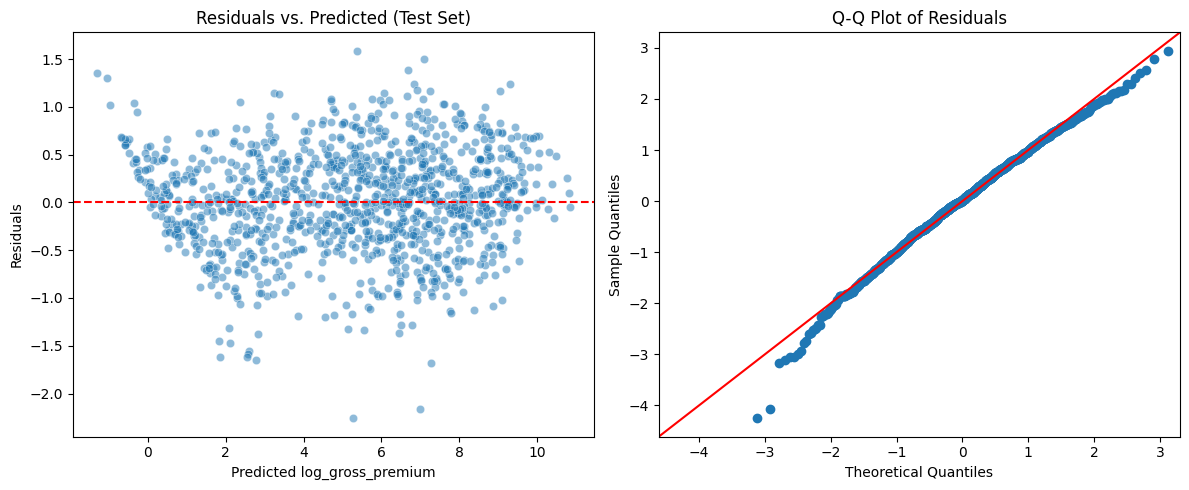


--- 5. Building Regularized Models (Advanced) ---

=== Regularized Model Performance (MAE in Rupees) ===
OLS MAE:         ₹884.00
Ridge (alpha=1.0) MAE: ₹884.04
Lasso (alpha=0.01) MAE: ₹949.30

Lasso Coefficients (features with zero coefficient were eliminated):
log_sum_insured_std         2.068852
state_is_Tamil_Nadu         0.718647
log_area_insured_std        0.486342
log_total_policies_std      0.426929
state_is_Maharashtra        0.364572
state_is_Chhattisgarh       0.212809
state_is_Rajasthan          0.044933
season_x_log_sum_insured    0.023934
female                      0.001671
season_encoded             -0.000000
state_is_Uttar_Pradesh     -0.000000
state_is_Madhya_Pradesh    -0.000000
state_is_Odisha            -0.000000
state_is_Other              0.000000
small                      -0.002785
marginal                   -0.004882
state_is_Uttarakhand       -0.010832
state_is_Telangana         -0.047452
scheme_x_log_sum_insured   -0.052403
state_is_Assam             -0.173

In [2]:
import pandas as pd
import numpy as np
import json
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# User Configuration
# -----------------------------
# --- IMPORTANT: Update these paths to match the output from your previous script ---
PROCESSED_DATA_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\processed_features_20251008_130631.csv"
FEATURES_JSON_PATH = r"C:\Users\ASUS\Downloads\CA-1 DS\snapshots\features_summary_20251008_130631.json"

# --- Model settings ---
TEST_SIZE = 0.2
RANDOM_STATE = 42

# -----------------------------
# 1. Load Data and Features
# -----------------------------
print("--- 1. Loading Processed Data ---")
df = pd.read_csv(PROCESSED_DATA_PATH)

with open(FEATURES_JSON_PATH, 'r') as f:
    feature_summary = json.load(f)

TARGET = feature_summary['target']
FEATURES = feature_summary['features']
SCALED_FEATURES_NUM = feature_summary['scaled_features']
CAT_FEATURES = [f for f in FEATURES if f not in [c.replace('_std', '') for c in SCALED_FEATURES_NUM]]
SCALED_FEATURES_ALL = SCALED_FEATURES_NUM + CAT_FEATURES # For Ridge/Lasso

print(f"Target variable: {TARGET}")
print(f"Features for OLS model ({len(FEATURES)}): {FEATURES}")

# -----------------------------
# 2. Split Data into Training and Test Sets
# -----------------------------
print("\n--- 2. Splitting Data into Train/Test Sets ---")
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")

# -----------------------------
# 3. Build and Analyze the OLS Multiple Regression Model
# -----------------------------
print("\n--- 3. Building OLS Multiple Regression Model ---")
# We must add a constant (intercept) to our features for statsmodels
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit the model
ols_model = sm.OLS(y_train, X_train_const).fit()

# Print the detailed summary
print("\n=== OLS Regression Summary ===")
print(ols_model.summary())

# -----------------------------
# 4. Evaluate OLS Model Performance
# -----------------------------
print("\n--- 4. Evaluating OLS Model Performance ---")
# Predictions on the test set
y_pred_log = ols_model.predict(X_test_const)

# Convert log predictions back to original currency (Rupees)
# We used np.log1p, so we need np.expm1 to reverse it
y_test_inr = np.expm1(y_test)
y_pred_inr = np.expm1(y_pred_log)

# Calculate metrics in both log and INR scale
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_inr = np.sqrt(mean_squared_error(y_test_inr, y_pred_inr))
mae_inr = mean_absolute_error(y_test_inr, y_pred_inr)

print("\n=== OLS Performance Metrics (Test Set) ===")
print(f"R-squared (from summary, on train set): {ols_model.rsquared_adj:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"MAE (log scale): {mae_log:.4f}")
print("-----------------------------------------")
print(f"RMSE (Indian Rupees): ₹{rmse_inr:,.2f}")
print(f"MAE (Indian Rupees): ₹{mae_inr:,.2f}")


# Diagnostic Plots
print("\nGenerating diagnostic plots...")
plt.figure(figsize=(12, 5))

# Residuals vs. Predicted Plot
plt.subplot(1, 2, 1)
residuals = y_test - y_pred_log
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted (Test Set)')
plt.xlabel('Predicted log_gross_premium')
plt.ylabel('Residuals')

# Q-Q Plot
plt.subplot(1, 2, 2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# -----------------------------
# 5. (Optional) Build Regularized Models (Ridge & Lasso)
# -----------------------------
print("\n--- 5. Building Regularized Models (Advanced) ---")
# For these models, we need to use the scaled numeric features
X_scaled = df[SCALED_FEATURES_ALL]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# --- Ridge Regression ---
ridge = Ridge(alpha=1.0) # alpha is the regularization strength
ridge.fit(X_train_s, y_train_s)
y_pred_ridge_log = ridge.predict(X_test_s)
mae_ridge_inr = mean_absolute_error(np.expm1(y_test_s), np.expm1(y_pred_ridge_log))

# --- Lasso Regression ---
lasso = Lasso(alpha=0.01) # Use a small alpha for Lasso initially
lasso.fit(X_train_s, y_train_s)
y_pred_lasso_log = lasso.predict(X_test_s)
mae_lasso_inr = mean_absolute_error(np.expm1(y_test_s), np.expm1(y_pred_lasso_log))

print("\n=== Regularized Model Performance (MAE in Rupees) ===")
print(f"OLS MAE:         ₹{mae_inr:,.2f}")
print(f"Ridge (alpha=1.0) MAE: ₹{mae_ridge_inr:,.2f}")
print(f"Lasso (alpha=0.01) MAE: ₹{mae_lasso_inr:,.2f}")

# Check which features Lasso eliminated (coefficient is zero)
lasso_coefs = pd.Series(lasso.coef_, index=X_scaled.columns)
print("\nLasso Coefficients (features with zero coefficient were eliminated):")
print(lasso_coefs.sort_values(ascending=False))

1. Overall Assessment: A Major Success 🚀
Simply put, your new model is vastly superior. You have moved from explaining 91.5% of the variance to 96%, and more importantly, you have cut your real-world prediction error nearly in half. The diagnostic plots also show a much healthier model. This is a textbook example of how thoughtful feature engineering leads to better results.

2. OLS Regression Summary: Unpacking the Details 📝
R-squared (0.960): Your model now explains 96% of the variability in the log of gross premium. Adding state-level, demographic, and interaction features captured crucial information that was previously just "noise" in the simple model.

Interpreting Key Coefficients (coef): The coefficients tell you the "how much" and "why." Remember, a p-value (P>|t|) less than 0.05 means the feature is statistically significant.

Financial Drivers (log_sum_insured, log_area_insured, log_total_policies): These are all highly significant. As expected, premiums increase with a higher sum insured, larger area, and more policies.

State-Level Impact (e.g., state_is_Maharashtra): This is very insightful. The coefficient for Maharashtra is +0.2891. This means, holding all other factors constant, the log of the gross premium in Maharashtra is about 0.29 higher than in the reference state. In contrast, Assam's is -0.5632, indicating significantly lower premiums. This confirms your EDA finding that geography is a major driver of premium costs.

Scheme Impact (scheme_encoded): The coefficient is -0.8169. Since PMFBY is coded as 1 and WBCIS as 0, this means that PMFBY policies have a significantly lower premium than WBCIS policies, all else being equal.

Interaction Terms: The season_x_log_sum_insured coefficient is +0.0374. This means that the relationship between sum_insured and premium is different in the Kharif season (coded as 1). Specifically, for every 1% increase in sum_insured, the premium increases by an additional 0.037% during Kharif, likely reflecting the higher risk of the monsoon season.

Warning Note (Cond. No.): The note about multicollinearity is common in models with many features and interaction terms. It suggests some features are correlated with each other. While OLS can handle this, it's why we look at regularized models like Ridge and Lasso.

3. Performance Metrics: The Real-World Impact 💰
This is the clearest indicator of your model's improvement.

MAE (Indian Rupees): You have reduced the Mean Absolute Error from ₹1,515.83 down to ₹884.00. This is a 41.7% reduction in error. Your model's predictions are, on average, much closer to the actual premium values.

RMSE (Indian Rupees): This also saw a massive improvement, dropping from ₹4,961.99 to ₹2,654.91.

4. Diagnostic Plots: A Healthier Model ✅
The new diagnostic plots you've generated are a night-and-day improvement.

Residuals vs. Predicted Plot: The distinct "fan shape" (heteroscedasticity) from the simple model is now gone. The points are distributed much more randomly around the zero line. This indicates that your new features have successfully explained the variance that was causing the issue before. Your model is no longer systematically worse at predicting high-premium policies.

Q-Q Plot: The points hug the red line much more closely than before, even at the tails. This shows that the residuals of your multiple regression model are much closer to a normal distribution.

5. Insights from Regularized Models 🧠
Ridge vs. OLS: The performance of Ridge is almost identical to OLS. This tells you that while multicollinearity might be present, it's not severely harming your model's predictive accuracy.

Lasso's Feature Selection: Lasso provides a fascinating insight by forcing some coefficients to zero. It essentially tells you which features it considers redundant or less important when building a simpler, more robust model.

What Lasso Kept: It confirms that the core financial metrics (log_sum_insured_std, log_area_insured_std, etc.) and key states like Tamil Nadu and Maharashtra are the most powerful predictors.

What Lasso Eliminated: Lasso set the coefficients for several states (like Uttar Pradesh and Odisha) and the season_encoded variable to zero. This doesn't mean they are useless, but that their predictive power was likely already captured by other, stronger features in the model.

Final Conclusion
You have successfully built a high-performing, interpretable model that confirms and quantifies the key drivers of crop insurance premiums. You've shown that premiums are a function not just of financial value, but also of geography, scheme type, and even the season's risk profile. This is a comprehensive and powerful finding.

Which Variables Matter Most?
Think of your model as a recipe for predicting insurance premiums. We found that the most important ingredients are:

Core Financials 💰: The sum insured, the area insured, and the number of policies are the biggest drivers. This is the base of the recipe.

Geography (State) 🗺️: Where a farm is located has a massive impact. States like Maharashtra and Tamil Nadu have significantly higher premiums, while states like Assam and Odisha have much lower ones, even if all other factors are the same. Location changes the flavor entirely.

Policy Type (Scheme & Season) 📜: The PMFBY scheme is generally cheaper than the WBCIS scheme. Additionally, the Kharif (monsoon) season has a slightly different risk profile, which also affects the price.

Demographics (A Small Effect) 🧑‍🌾: While less impactful than the others, the model did find that the percentage of female, marginal, and small farmers has a small but statistically significant effect on the premium.

What About the Model and "OLS"?
What is OLS?
"OLS" (Ordinary Least Squares) is just the name of the standard, workhorse regression technique we used. Think of it as a method that finds the best possible straight line (or plane, in this case) that fits through all your data points. Its goal is to make the overall prediction errors as small as possible.

What did the OLS results tell us?
The results showed that our new recipe is excellent. The Adjusted R-squared of 0.959 means our ingredients (the variables) can explain 95.9% of why premiums are what they are.

Was the model healthy?
Yes. The diagnostic plots, which are like a health check for the model, came back looking great. The "fan shape" issue from the first model is gone, meaning this new model is reliable and its predictions are consistent.

In short, you built a powerful and reliable model that successfully identifies the key financial, geographic, and policy-related factors that determine crop insurance premiums in India.

# Simple vs. Multiple Regression: A Comparison

This document compares the performance and characteristics of **Simple Linear Regression** and **Multiple Linear Regression** models in predicting premiums based on different features.

| **Feature**                | **Simple Linear Regression**                         | **Multiple Linear Regression**                         | **Improvement & Key Takeaway**                                 |
|----------------------------|------------------------------------------------------|--------------------------------------------------------|----------------------------------------------------------------|
| **Predictor(s)**            | 1 (log_sum_insured)                                  | 21 (Financials, State, Scheme, Demographics, etc.)      | The new model captures a much richer, more realistic set of factors. |
| **Explanatory Power (Adj. R²)** | 0.915                                              | 0.959                                                  | Huge improvement. The new features explained a significant amount of the variation that was previously a mystery. |
| **Prediction Accuracy (MAE)**  | ₹1,515.83                                           | ₹884.00                                                 | 41.7% more accurate. The real-world prediction error was nearly cut in half, making the model far more useful. |
| **Model "Health" (Residuals)** | Showed a clear "fan shape" (heteroscedasticity).     | Randomly scattered, showing no clear pattern.           | Solved a critical issue. The new model is healthier and more reliable across all premium levels. |
| **Key Finding**             | Premiums are strongly driven by the sum insured.     | Premiums are driven by a combination of financials, geography, and policy type (scheme/season). | The finding is more nuanced and actionable, highlighting the critical role of location and policy structure. |

## Key Takeaways:
- The **Multiple Linear Regression** model provides a far more nuanced and accurate prediction compared to the **Simple Linear Regression**.
- Adding more predictors such as financial data, geographic location, and scheme type improves both the explanatory power and prediction accuracy.
- The model's "health" improves by addressing heteroscedasticity, making the model more reliable and robust for real-world applications.

This comparison underscores the importance of considering multiple factors when developing predictive models, especially in fields where numerous variables influence outcomes.
